# This is a framework for detecting and eliminating Majority Iluusions in social network graphs and simulating opinion cascades using OpenAI API LLM-based agents

# Scalable Majority Illusion Elimination

This notebook implements the experiments accompanying my Master's thesis
at the New Economic School.

The project studies whether a structural intervention in a social graph
can eliminate majority illusion and affect subsequent opinion cascades.

1. Setup
2. Data loading
3. Graph preprocessing
4. Majority illusion definition
5. Louvain community detection
6. Exact local MIE optimization
7. Community-level experiment
8. LLM-agent simulation
9. Original vs. treated graph
10. Results
11. Limitations

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain
from itertools import combinations

from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import lil_array
from collections import defaultdict

## Download instagram graph

In [68]:
network_lt_df = pd.read_csv("Network for IC LT.txt", sep=r'\s+', header=None, names=["source", "target", "weight"], skiprows=1)
network_lt_u_df = pd.read_csv("Network for IC-u LT-u.txt", sep=r'\s+', header=None, names=["source", "target", "weight"], skiprows=1)
user_stats_df = pd.read_csv("Instagram User Stats.csv")

In [69]:
G_lt = nx.from_pandas_edgelist(network_lt_df, source="source", target="target", edge_attr="weight", create_using=nx.DiGraph())
G_lt_u = nx.from_pandas_edgelist(network_lt_u_df, source="source", target="target", edge_attr="weight", create_using=nx.DiGraph())

# Add user stats as node attributes to the base graph G_lt
user_stats_df.set_index('id', inplace=True)
user_stats_dict = user_stats_df.to_dict(orient='index')
nx.set_node_attributes(G_lt, user_stats_dict)

# Verify the data structure by printing sample node attributes and edges
print("Sample node attributes in G_lt:\n", list(G_lt.nodes(data=True))[:5])
print("Sample edges with weights in G_lt\n:", list(G_lt.edges(data=True))[:5])

Sample node attributes in G_lt:
 [(1, {'pos': 702, 'flr': 906, 'flg': 677, 'eg': 0.1891, 'er': 6.07064, 'fg': 1.17786, 'op': 14.8936}), (2, {'pos': 160, 'flr': 386, 'flg': 713, 'eg': 0.195, 'er': 6.2608, 'fg': 0.0941265, 'op': 16.9811}), (3, {'pos': 851, 'flr': 20400, 'flg': 3700, 'eg': 0.0664, 'er': 0.717416, 'fg': 2.24244, 'op': 38.2166}), (69, {'pos': 354, 'flr': 3000, 'flg': 7500, 'eg': 0.0157, 'er': 0.283333, 'fg': 0.6432, 'op': 90.0}), (72, {'pos': 71, 'flr': 572, 'flg': 4800, 'eg': 0.2717, 'er': 8.72183, 'fg': -0.776398, 'op': 46.4286})]
Sample edges with weights in G_lt
: [(1, 2, {'weight': 0.0833}), (1, 3, {'weight': 0.05}), (2, 69, {'weight': 0.0005}), (2, 72, {'weight': 0.0008}), (2, 77, {'weight': 0.0006})]


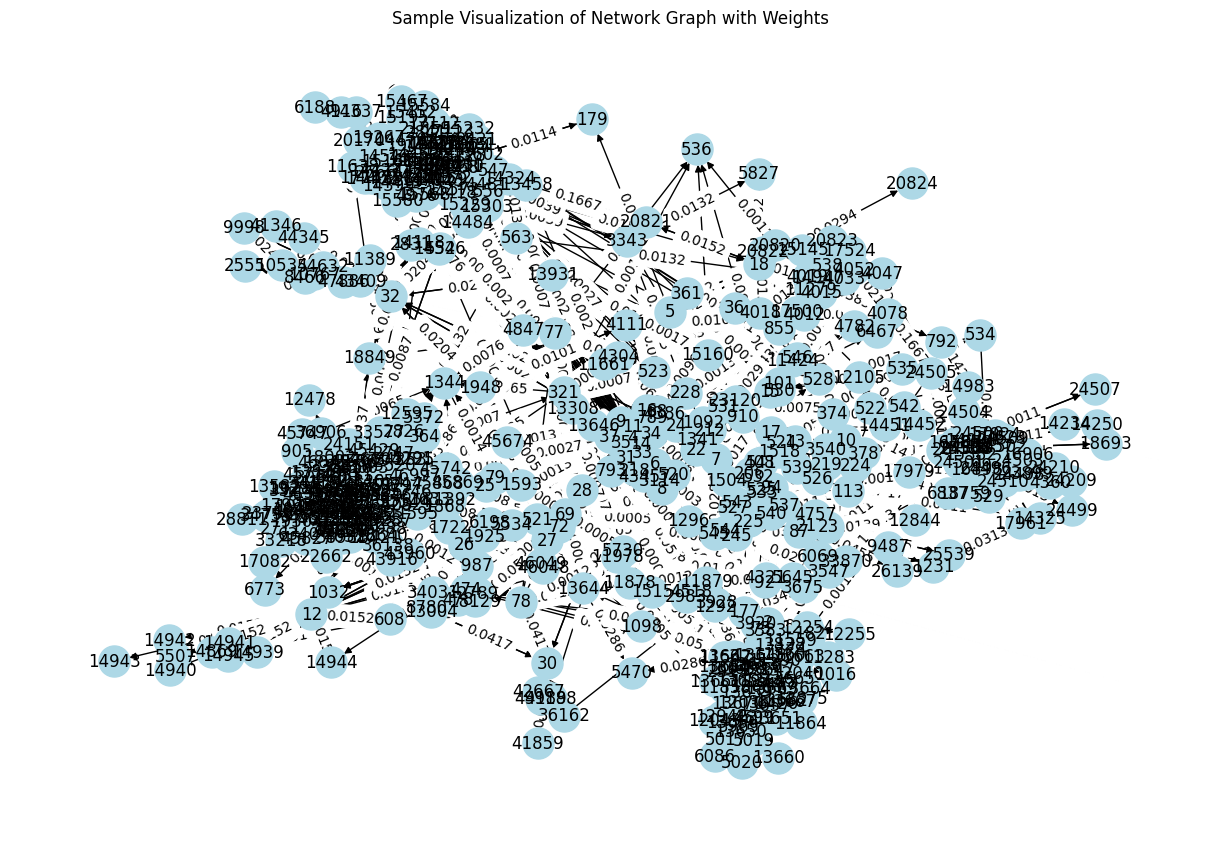

In [70]:
sample_nodes = list(G_lt.nodes())[:500]  # Choose a subset for visualization
sample_graph = G_lt.subgraph(sample_nodes)
pos = nx.spring_layout(sample_graph)

plt.figure(figsize=(12, 8))
nx.draw(sample_graph, pos, with_labels=True, node_size=500, node_color="lightblue")
edge_labels = nx.get_edge_attributes(sample_graph, "weight")
nx.draw_networkx_edge_labels(sample_graph, pos, edge_labels=edge_labels)
plt.title("Sample Visualization of Network Graph with Weights")
plt.show()

In [71]:
print("nodes:", G_lt.number_of_nodes())
print("edges:", G_lt.number_of_edges())

density = nx.density(G_lt)
print("density:", density)

nodes: 70409
edges: 1031348
density: 0.00020804392877689116


avg in-degree: 14.647956937323354
avg out-degree: 14.647956937323354
max in-degree: 2043
max out-degree: 7620


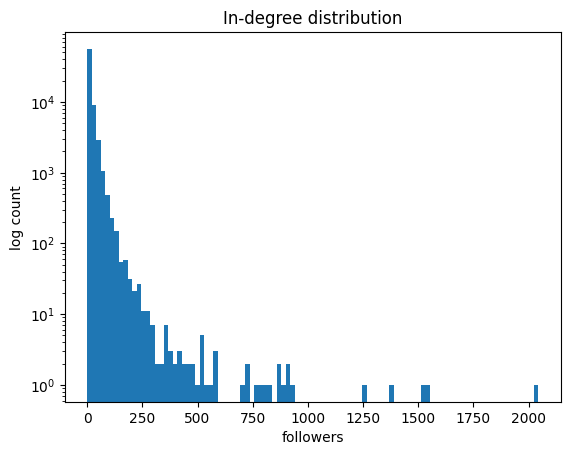

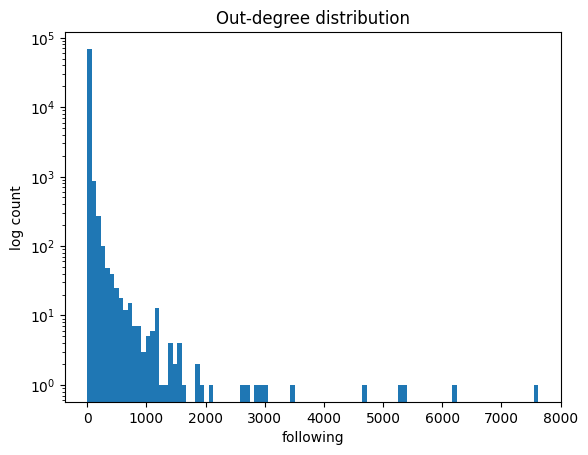

In [72]:
in_degrees = np.array([d for _, d in G_lt.in_degree()])
out_degrees = np.array([d for _, d in G_lt.out_degree()])

print("avg in-degree:", in_degrees.mean())
print("avg out-degree:", out_degrees.mean())
print("max in-degree:", in_degrees.max())
print("max out-degree:", out_degrees.max())

plt.figure()
plt.hist(in_degrees, bins=100, log=True)
plt.title("In-degree distribution")
plt.xlabel("followers")
plt.ylabel("log count")
plt.show()

plt.figure()
plt.hist(out_degrees, bins=100, log=True)
plt.title("Out-degree distribution")
plt.xlabel("following")
plt.ylabel("log count")
plt.show()

In [73]:
reciprocity = nx.reciprocity(G_lt)
print("reciprocity:", reciprocity)

clustering = nx.average_clustering(G_lt.to_undirected())
print("clustering:", clustering)

largest_cc = max(nx.weakly_connected_components(G_lt), key=len)
giant_component_ratio = len(largest_cc) / G_lt.number_of_nodes()
print("giant component ratio:", giant_component_ratio)

assortativity_degree = nx.degree_assortativity_coefficient(G_lt)
print("assortativity degree:", assortativity_degree)

partition = community_louvain.best_partition(G_lt.to_undirected())
modularity = community_louvain.modularity(
    partition,
    G_lt.to_undirected()
)
print("modularity:", modularity)

reciprocity: 0.32087326489216056
clustering: 0.1283055616461106
giant component ratio: 0.9986791461318866
assortativity degree: -0.07601891730955679
modularity: 0.5707181693457197


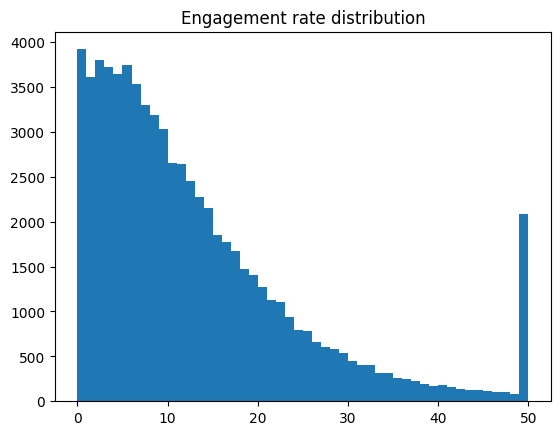

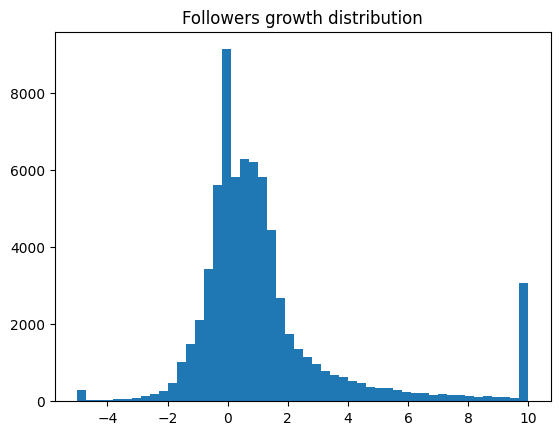

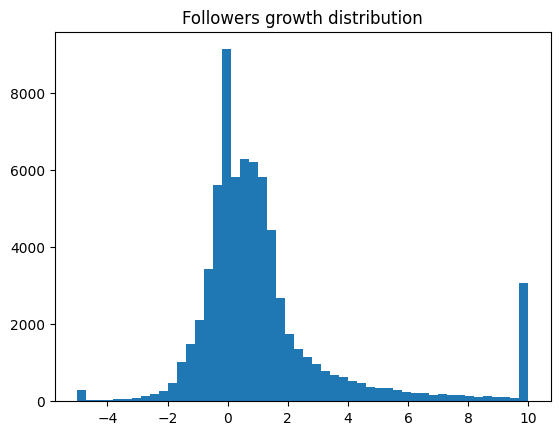

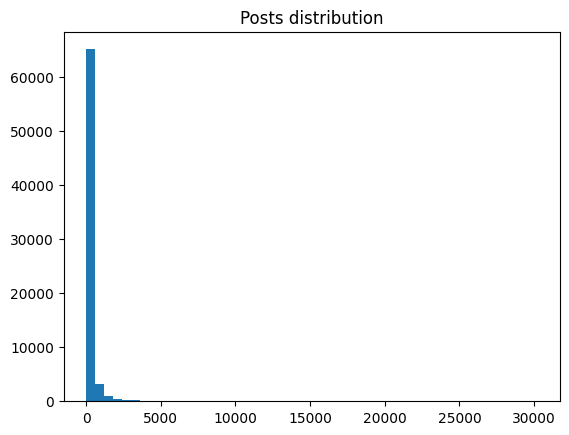

In [74]:
plt.figure()
plt.hist(user_stats_df.er, bins=50)
plt.title("Engagement rate distribution")
plt.show()

plt.figure()
plt.hist(user_stats_df.fg, bins=50)
plt.title("Followers growth distribution")
plt.show()

plt.figure()
plt.hist(user_stats_df.fg, bins=50)
plt.title("Followers growth distribution")
plt.show()

plt.figure()
plt.hist(user_stats_df.pos, bins=50)
plt.title("Posts distribution")
plt.show()

## Algorithm for elimination illusion

In [90]:
# Для Louvain обычно используем undirected version графа
G_und = G_lt.to_undirected()

# Louvain partition
partition = community_louvain.best_partition(G_und, random_state=42)

# сохранить community как атрибут вершины
nx.set_node_attributes(G_lt, partition, "community")
nx.set_node_attributes(G_und, partition, "community")

In [91]:
communities = defaultdict(list)

for node, comm_id in partition.items():
    communities[comm_id].append(node)

# размеры communities
community_sizes = [len(nodes) for nodes in communities.values()]

print("\nCommunity size stats:")
print("min:", np.min(community_sizes))
print("median:", np.median(community_sizes))
print("max:", np.max(community_sizes))
print("mean:", np.mean(community_sizes))


Community size stats:
min: 2
median: 2.0
max: 16545
mean: 437.3229813664596


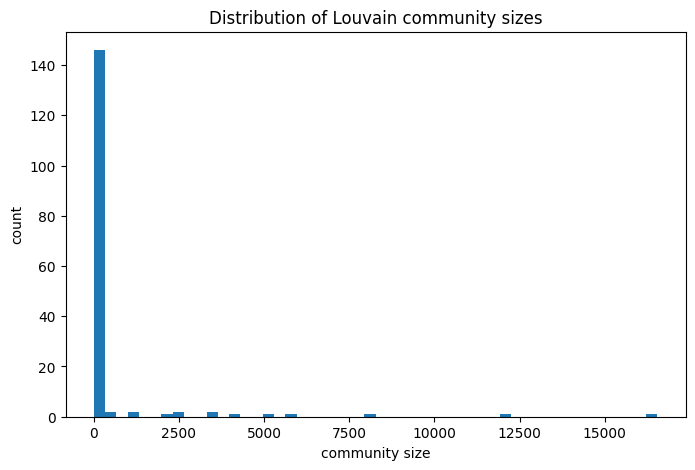

In [92]:
plt.figure(figsize=(8,5))

plt.hist(
    community_sizes,
    bins=50
)

plt.xlabel("community size")
plt.ylabel("count")
plt.title("Distribution of Louvain community sizes")

plt.show()

In [126]:
MIN_SIZE = 10
MAX_SIZE = 10000

selected_communities = {
    cid: nodes
    for cid, nodes in communities.items()
    if MIN_SIZE <= len(nodes) <= MAX_SIZE
}

print("\nSelected communities:", len(selected_communities))


Selected communities: 22


In [127]:
community_graphs = {}

for cid, nodes in selected_communities.items():

    subgraph = G_lt.subgraph(nodes).copy()

    community_graphs[cid] = subgraph

In [95]:
def initialize_binary_opinions(H: nx.Graph, negative_share: float = 0.2, seed: int = 42):
    """
    0 = blue / positive
    1 = red / negative
    """
    rng = np.random.default_rng(seed)
    nodes = list(H.nodes())
    n_red = max(1, int(round(len(nodes) * negative_share)))
    red_nodes = set(rng.choice(nodes, size=n_red, replace=False))
    labels = {v: (1 if v in red_nodes else 0) for v in nodes}
    return labels

In [96]:
def count_majority_illusion_nodes(H: nx.Graph, labels: dict):
    illusion_nodes = []
    deficits = {}
    
    for v in H.nodes():
        nbrs = list(H.neighbors(v))
        if len(nbrs) == 0:
            deficits[v] = 0
            continue
        
        red_n = sum(labels[u] == 1 for u in nbrs)
        blue_n = sum(labels[u] == 0 for u in nbrs)
        
        deficits[v] = max(red_n - blue_n, 0)
        if red_n > blue_n:
            illusion_nodes.append(v)
    
    return illusion_nodes, deficits

In [97]:
def summarize_labels(H: nx.Graph, labels: dict):
    n = H.number_of_nodes()
    n_red = sum(labels[v] == 1 for v in H.nodes())
    n_blue = n - n_red
    illusion_nodes, deficits = count_majority_illusion_nodes(H, labels)
    
    return {
        "n_nodes": n,
        "n_edges": H.number_of_edges(),
        "red_share": n_red / n,
        "blue_share": n_blue / n,
        "illusion_count": len(illusion_nodes),
        "illusion_share": len(illusion_nodes) / n,
        "avg_deficit": np.mean(list(deficits.values())) if deficits else 0.0
    }

In [98]:
def solve_local_mie_exact(H: nx.Graph, labels: dict, verbose: bool = False):
    """
    Exact local MIE on undirected community graph using MILP.

    Allowed operations:
      - add blue-blue nonedges
      - remove red-red existing edges

    Returns:
      result dict with added_edges, removed_edges, modified graph, stats
    """
    H = H.copy()
    nodes = list(H.nodes())

    blue_nodes = [v for v in nodes if labels[v] == 0]
    red_nodes  = [v for v in nodes if labels[v] == 1]

    illusion_nodes, deficits = count_majority_illusion_nodes(H, labels)

    if verbose:
        print("Initial illusion nodes:", len(illusion_nodes))

    # Candidate additions: missing blue-blue edges
    add_candidates = []
    for u, v in combinations(blue_nodes, 2):
        if not H.has_edge(u, v):
            add_candidates.append((u, v))

    # Candidate removals: existing red-red edges
    remove_candidates = []
    for u, v in combinations(red_nodes, 2):
        if H.has_edge(u, v):
            remove_candidates.append((u, v))

    n_add = len(add_candidates)
    n_rem = len(remove_candidates)
    n_vars = n_add + n_rem

    if verbose:
        print("Add candidates:", n_add)
        print("Remove candidates:", n_rem)

    # quick infeasibility checks
    for v in blue_nodes:
        if deficits[v] > 0:
            possible = sum(v in e for e in add_candidates)
            if possible < deficits[v]:
                return {
                    "status": "infeasible_blue",
                    "reason": f"blue node {v} deficit {deficits[v]} > possible additions {possible}"
                }

    for v in red_nodes:
        if deficits[v] > 0:
            possible = sum(v in e for e in remove_candidates)
            if possible < deficits[v]:
                return {
                    "status": "infeasible_red",
                    "reason": f"red node {v} deficit {deficits[v]} > possible removals {possible}"
                }

    if n_vars == 0:
        return {
            "status": "optimal",
            "added_edges": [],
            "removed_edges": [],
            "graph": H,
            "before_stats": summarize_labels(H, labels),
            "after_stats": summarize_labels(H, labels),
            "objective": 0
        }

    # Objective: minimize number of modifications
    c = np.ones(n_vars, dtype=float)

    constraints = []

    # Blue constraints: incident additions >= deficit
    for v in blue_nodes:
        d = deficits[v]
        if d <= 0:
            continue
        row = np.zeros(n_vars, dtype=float)
        for idx, e in enumerate(add_candidates):
            if v in e:
                row[idx] = 1.0
        constraints.append(LinearConstraint(row, lb=d, ub=np.inf))

    # Red constraints: incident removals >= deficit
    for v in red_nodes:
        d = deficits[v]
        if d <= 0:
            continue
        row = np.zeros(n_vars, dtype=float)
        for jdx, e in enumerate(remove_candidates):
            if v in e:
                row[n_add + jdx] = 1.0
        constraints.append(LinearConstraint(row, lb=d, ub=np.inf))

    integrality = np.ones(n_vars, dtype=int)
    bounds = Bounds(lb=np.zeros(n_vars), ub=np.ones(n_vars))

    res = milp(
        c=c,
        constraints=constraints,
        integrality=integrality,
        bounds=bounds
    )

    if not res.success:
        return {
            "status": "solver_failed",
            "reason": res.message
        }

    x = np.rint(res.x).astype(int)

    added_edges = [add_candidates[i] for i in range(n_add) if x[i] == 1]
    removed_edges = [remove_candidates[j] for j in range(n_rem) if x[n_add + j] == 1]

    # Apply modifications
    H_new = H.copy()
    H_new.add_edges_from(added_edges)
    H_new.remove_edges_from(removed_edges)

    before_stats = summarize_labels(H, labels)
    after_stats = summarize_labels(H_new, labels)

    return {
        "status": "optimal",
        "added_edges": added_edges,
        "removed_edges": removed_edges,
        "graph": H_new,
        "before_stats": before_stats,
        "after_stats": after_stats,
        "objective": int(np.sum(x))
    }

In [99]:
def prepare_test_communities(community_graphs, min_size=100, max_size=300, max_count=5):
    """
    Select several small/medium communities for exact MIE testing.
    """
    eligible = []
    for cid, Gc in community_graphs.items():
        n = Gc.number_of_nodes()
        if min_size <= n <= max_size:
            eligible.append((cid, n))
    
    eligible = sorted(eligible, key=lambda x: x[1])
    selected_ids = [cid for cid, _ in eligible[:max_count]]
    return selected_ids

In [100]:
test_ids = prepare_test_communities(
    community_graphs,
    min_size=100,
    max_size=10000,
    max_count=200
)

In [101]:
test_results = []

for idx, cid in enumerate(test_ids):
    print(f"\n=== COMMUNITY {cid} ({idx+1}/{len(test_ids)}) ===")

    # Для MIE используем undirected version community
    Gc = community_graphs[cid].to_undirected()
    
    labels = initialize_binary_opinions(
        Gc,
        negative_share=0.2,
        seed=42 + idx
    )
    
    result = solve_local_mie_exact(Gc, labels, verbose=True)
    
    if result["status"] != "optimal":
        print("Failed:", result)
        continue
    
    print("Size of commmunity:", Gc.number_of_nodes())
    print("Number of edges:", Gc.number_of_edges())
    print("Objective value:", result["objective"])
    print("Added edges:", len(result["added_edges"]))
    print("Removed edges:", len(result["removed_edges"]))
    print("Before illusion count:", result["before_stats"]["illusion_count"])
    print("After illusion count:", result["after_stats"]["illusion_count"])

    test_results.append({
        "community": cid,
        "size": Gc.number_of_nodes(),
        "edges": Gc.number_of_edges(),
        "objective": result["objective"],
        "added": len(result["added_edges"]),
        "removed": len(result["removed_edges"]),
        "before_illusion": result["before_stats"]["illusion_count"],
        "after_illusion": result["after_stats"]["illusion_count"],
        "red_share": result["before_stats"]["red_share"]
    })


=== COMMUNITY 6 (1/17) ===
Initial illusion nodes: 4
Add candidates: 3236
Remove candidates: 1
Size of commmunity: 103
Number of edges: 115
Objective value: 2
Added edges: 2
Removed edges: 0
Before illusion count: 4
After illusion count: 0

=== COMMUNITY 21 (2/17) ===
Initial illusion nodes: 88
Add candidates: 15143
Remove candidates: 24
Size of commmunity: 219
Number of edges: 236
Objective value: 59
Added edges: 44
Removed edges: 15
Before illusion count: 88
After illusion count: 0

=== COMMUNITY 23 (3/17) ===
Initial illusion nodes: 16
Add candidates: 18351
Remove candidates: 9
Size of commmunity: 241
Number of edges: 270
Objective value: 9
Added edges: 8
Removed edges: 1
Before illusion count: 16
After illusion count: 0

=== COMMUNITY 18 (4/17) ===
Initial illusion nodes: 19
Add candidates: 23008
Remove candidates: 54
Size of commmunity: 272
Number of edges: 1124
Objective value: 12
Added edges: 10
Removed edges: 2
Before illusion count: 19
After illusion count: 0

=== COMMUNITY 1

In [37]:
def plot_local_mie_before_after(G_before, G_after, labels, title_prefix="Community"):
    pos = nx.spring_layout(G_before, seed=42)

    colors = ["red" if labels[v] == 1 else "blue" for v in G_before.nodes()]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    nx.draw(
        G_before,
        pos,
        node_color=colors,
        node_size=80,
        ax=axes[0]
    )
    axes[0].set_title(f"{title_prefix}: before MIE")
    axes[0].axis("off")

    nx.draw(
        G_after,
        pos,
        node_color=colors,
        node_size=80,
        ax=axes[1]
    )
    axes[1].set_title(f"{title_prefix}: after MIE")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

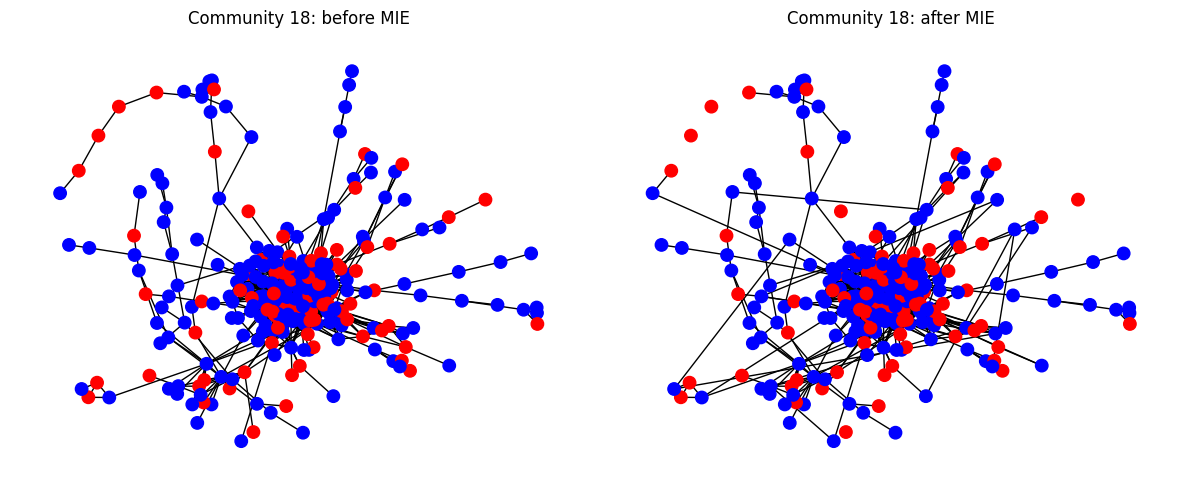

In [38]:
if len(test_ids) > 0:
    cid = test_ids[3]
    Gc = community_graphs[cid].to_undirected()
    labels = initialize_binary_opinions(Gc, negative_share=0.3, seed=42)
    result = solve_local_mie_exact(Gc, labels, verbose=False)

    if result["status"] == "optimal":
        plot_local_mie_before_after(
            Gc,
            result["graph"],
            labels,
            title_prefix=f"Community {cid}"
        )

In [39]:
def visualize_mie_changes(
    G_before,
    result,
    labels,
    title="MIE modifications"
):

    G_after = result["graph"]

    illusion_nodes, _ = count_majority_illusion_nodes(G_before, labels)

    added_edges = result["added_edges"]
    removed_edges = result["removed_edges"]

    pos = nx.spring_layout(G_before, seed=42)

    # цвета ВСЕХ узлов
    node_colors = [
        "red" if labels[v] == 1 else "blue"
        for v in G_before.nodes()
    ]

    fig, ax = plt.subplots(figsize=(7,7))

    # базовые рёбра
    nx.draw_networkx_edges(
        G_before,
        pos,
        alpha=0.35,
        ax=ax
    )

    # удалённые рёбра
    if len(removed_edges) > 0:
        nx.draw_networkx_edges(
            G_before,
            pos,
            edgelist=removed_edges,
            edge_color="red",
            width=2,
            style="dashed",
            ax=ax
        )

    # добавленные рёбра
    if len(added_edges) > 0:
        nx.draw_networkx_edges(
            G_after,
            pos,
            edgelist=added_edges,
            edge_color="green",
            width=2,
            ax=ax
        )

    # все вершины
    nx.draw_networkx_nodes(
        G_before,
        pos,
        node_color=node_colors,
        node_size=120,
        ax=ax
    )

    # отдельно рисуем вершины под иллюзией
    if len(illusion_nodes) > 0:

        illusion_colors = [
            "red" if labels[v] == 1 else "blue"
            for v in illusion_nodes
        ]

        nx.draw_networkx_nodes(
            G_before,
            pos,
            nodelist=illusion_nodes,
            node_color=illusion_colors,
            node_size=220,
            edgecolors="yellow",
            linewidths=2.5,
            ax=ax
        )

    ax.set_title(title)
    ax.axis("off")

    plt.show()


Visualizing community 6


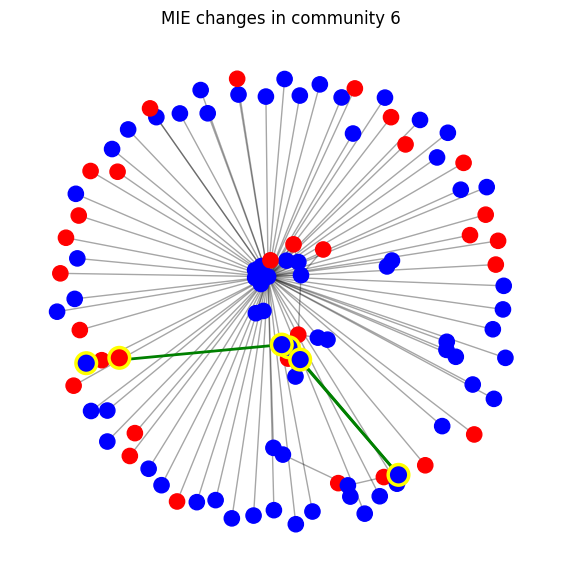


Visualizing community 21


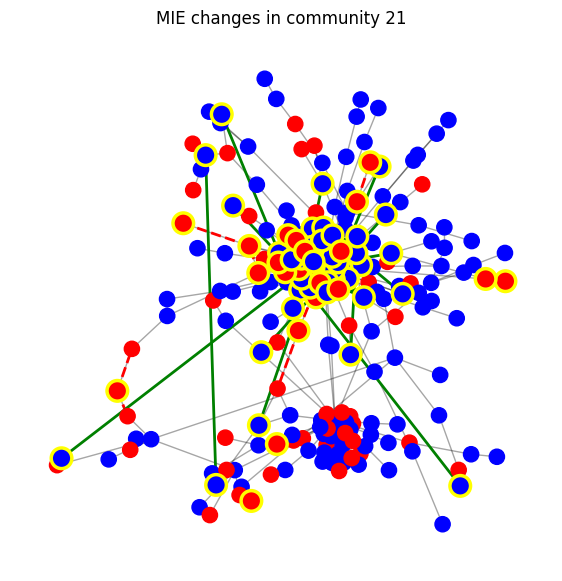


Visualizing community 23


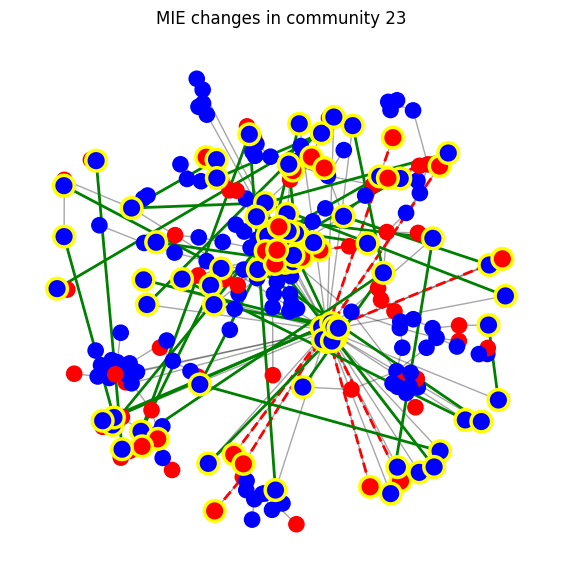


Visualizing community 18


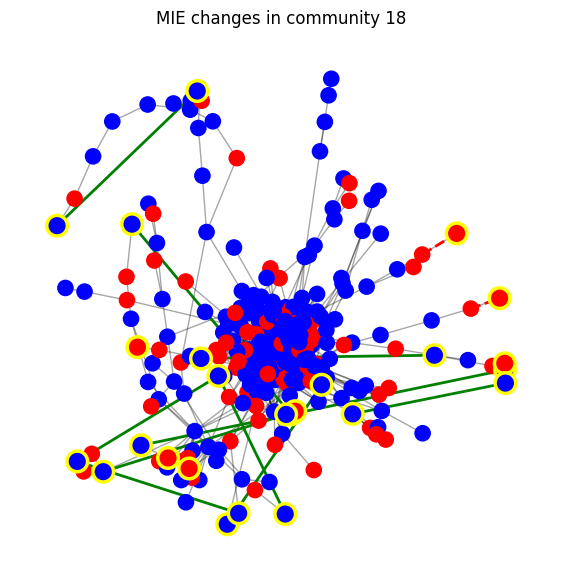


Visualizing community 16


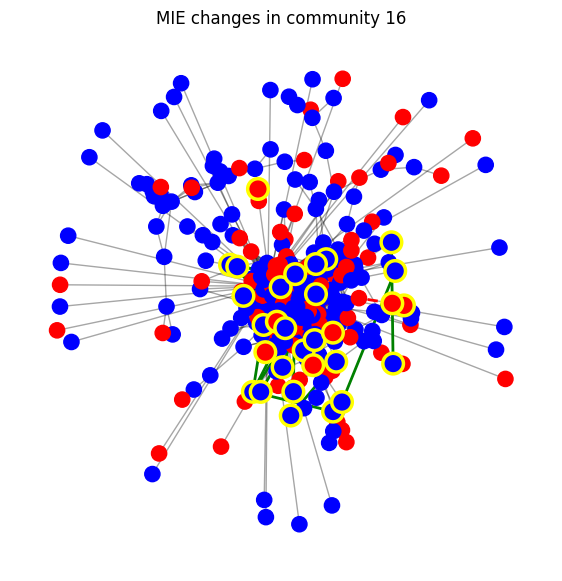


Visualizing community 4


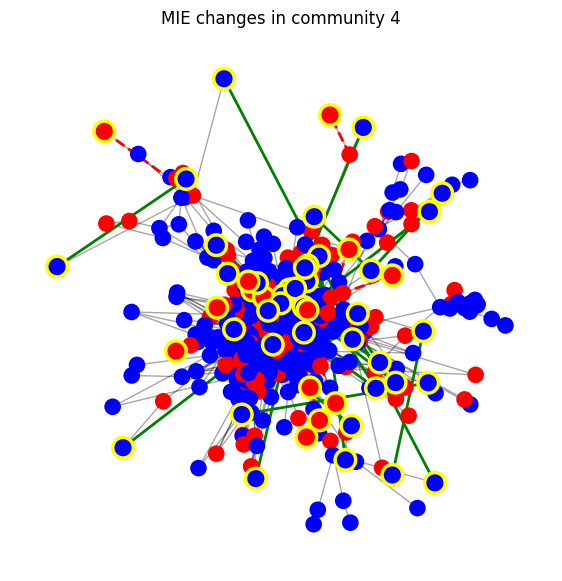


Visualizing community 11


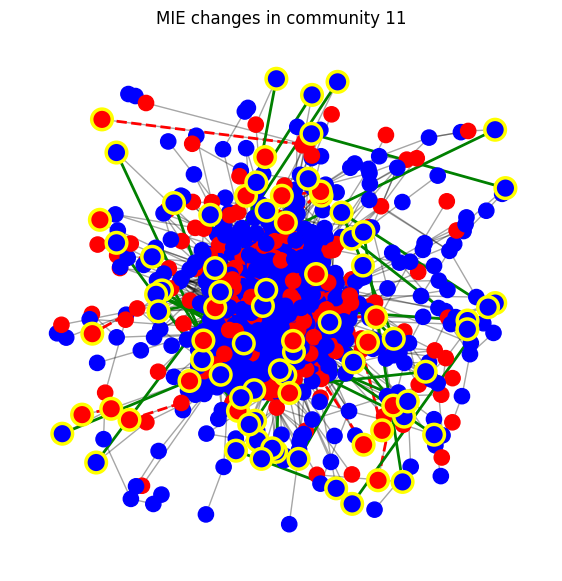


Visualizing community 27


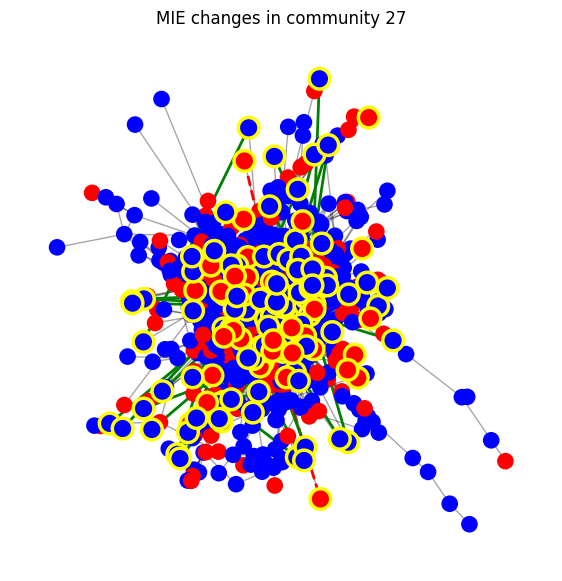


Visualizing community 3


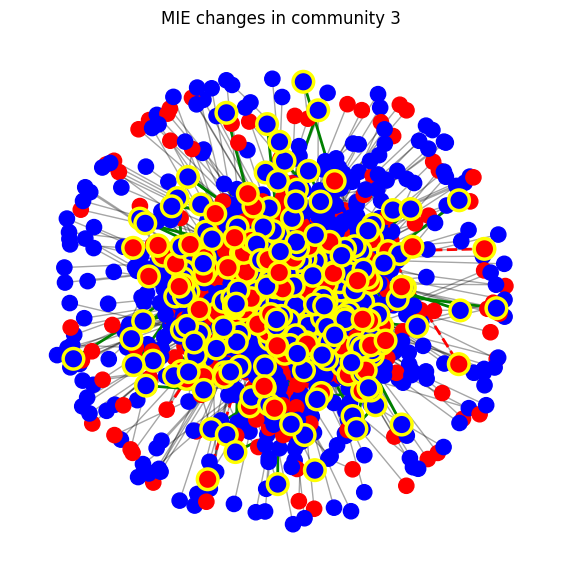


Visualizing community 12


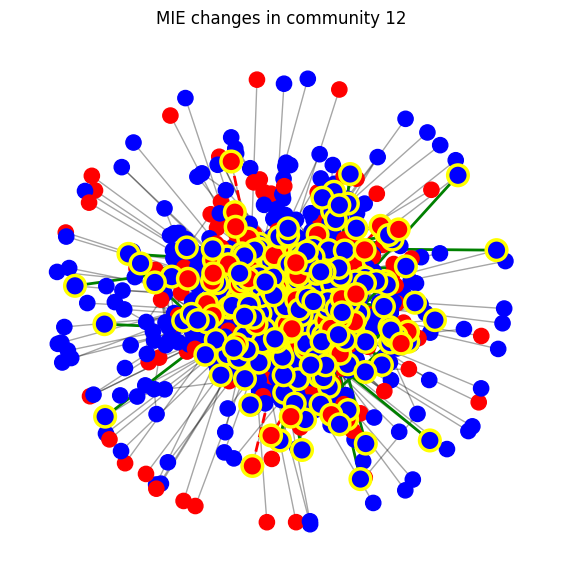


Visualizing community 29


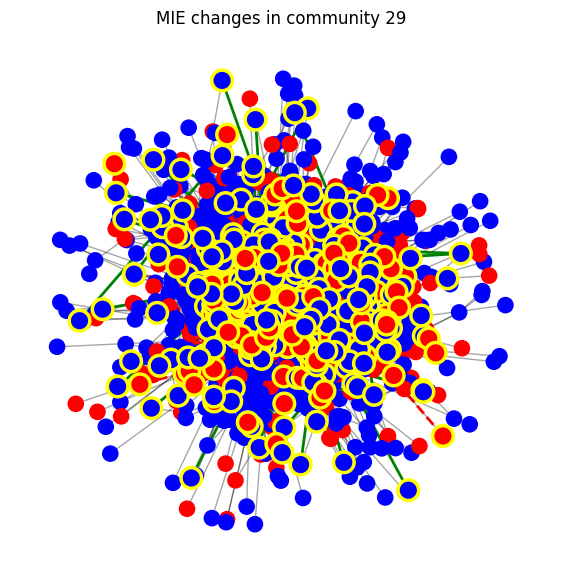


Visualizing community 7


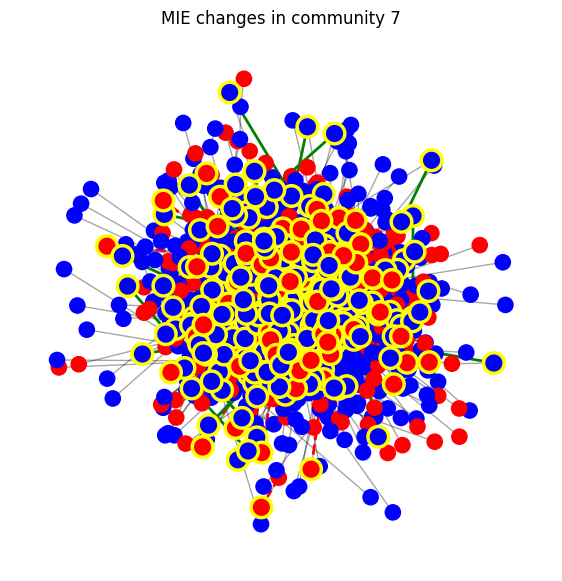


Visualizing community 1


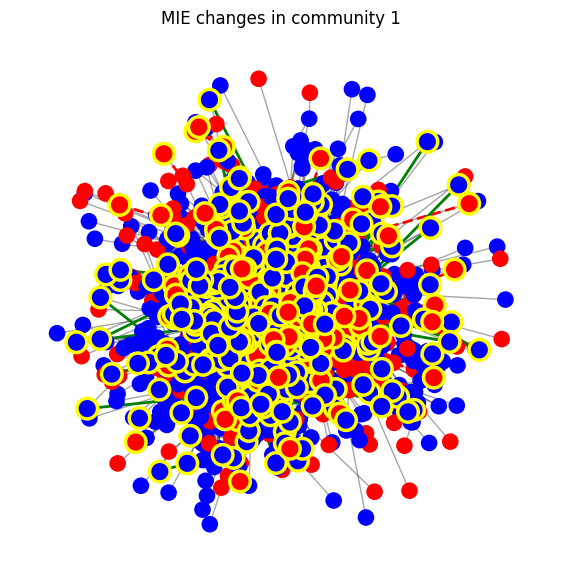


Visualizing community 0


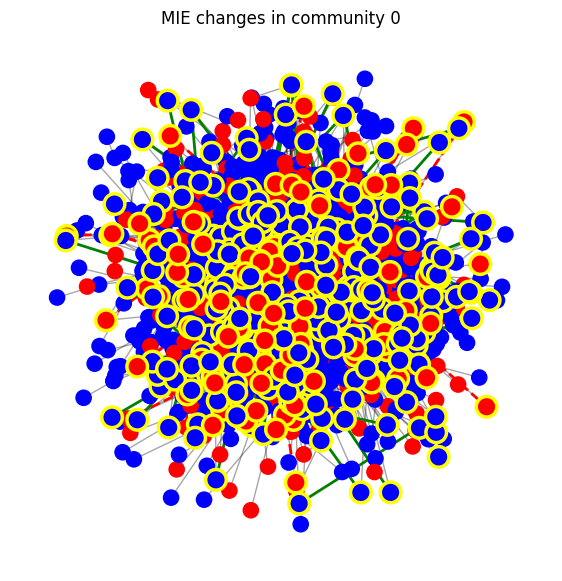


Visualizing community 8


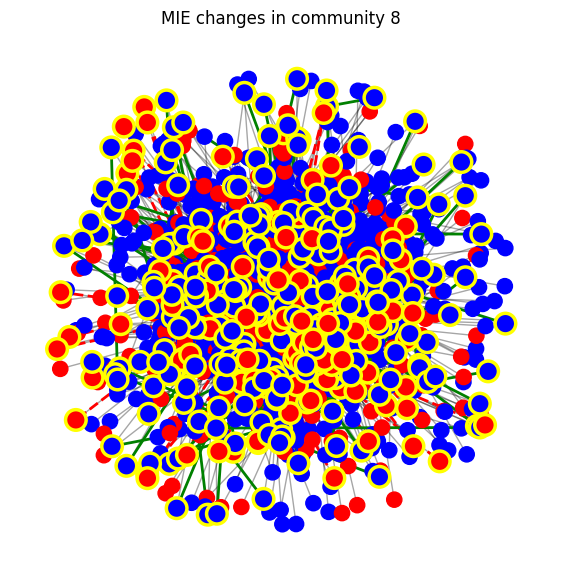


Visualizing community 2


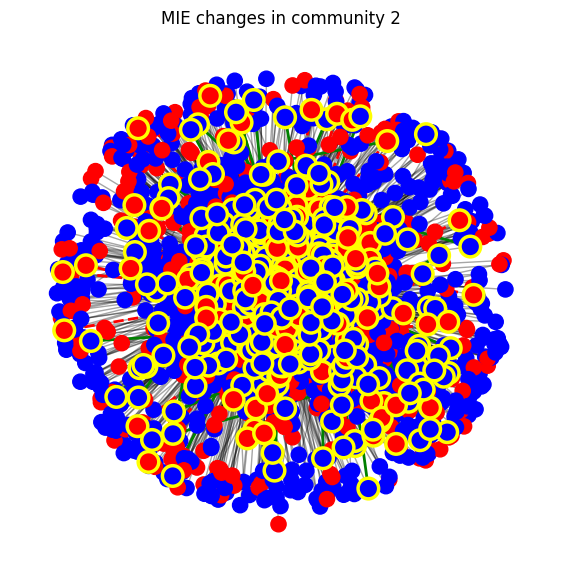


Visualizing community 13


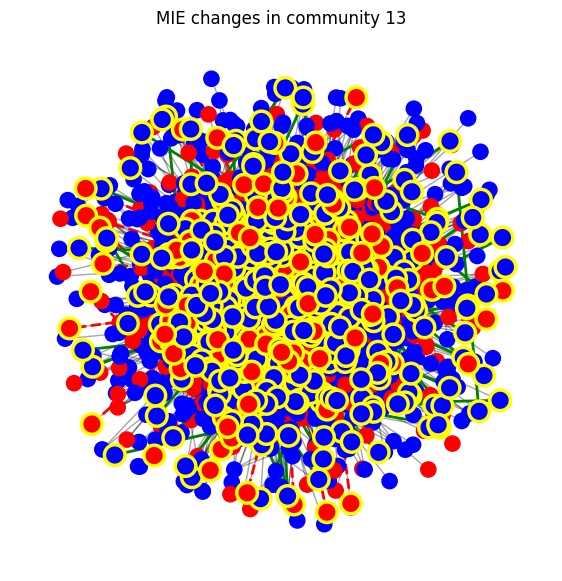

In [40]:
for cid in test_ids[:]:

    print("\nVisualizing community", cid)

    Gc = community_graphs[cid].to_undirected()

    labels = initialize_binary_opinions(
        Gc,
        negative_share=0.3,
        seed=42 + cid
    )

    result = solve_local_mie_exact(Gc, labels)

    if result["status"] == "optimal":

        visualize_mie_changes(
            Gc,
            result,
            labels,
            title=f"MIE changes in community {cid}"
        )

# Setup simulation

In [140]:
class Post:
    def __init__(
        self,
        author,
        opinion,
        text,
        time,
        engagement
    ):

        self.author = author
        self.opinion = opinion
        self.text = text
        self.time = time
        self.engagement = engagement

In [141]:
def will_post(agent):

    base = agent.get("posts", 1)
    prob = min(0.7, 0.02 + base / 500)

    return np.random.rand() < prob

In [142]:
def rank_posts(
    user,
    candidate_posts,
    G,
    feed_size=20
):

    scores = []
    user_opinion = G.nodes[user]["opinion"]

    for post in candidate_posts:

        similarity = 1 - abs(post.opinion - user_opinion)
        engagement = post.engagement
        recency = 1 / (1 + post.time)
        relationship = (
            1 if G.has_edge(user, post.author)
            else 0.3
        )

        score = (
            0.1 * similarity
            + 0.1 * engagement
            + 0.1 * recency
            + 0.7 * relationship
        )

        scores.append((post, score))

    scores.sort(key=lambda x: x[1], reverse=True)

    return [p for p,_ in scores[:feed_size]]

In [145]:
class SimulationStats:

    def __init__(self):

        self.posts_per_step = []
        self.follow_events = []
        self.unfollow_events = []
        self.opinion_switches = []
        self.api_calls_post = 0
        self.api_calls_opinion = 0
        self.sample_posts = []

In [143]:
def maybe_follow(user, post, G, stats):

    diff = abs(G.nodes[user]["opinion"] - post.opinion)
    prob = 0.2 + 0.6*(1-diff)

    if np.random.rand() < prob:
        if not G.has_edge(user, post.author):
            G.add_edge(user, post.author)
            stats.follow_events[-1] += 1

In [144]:
def maybe_unfollow(user, target, G, stats):

    diff = abs(G.nodes[user]["opinion"] - G.nodes[target]["opinion"])
    prob = 0.02 + 0.25*diff

    if np.random.rand() < prob:
        if G.has_edge(user, target):
            G.remove_edge(user, target)
            stats.unfollow_events[-1] += 1

In [81]:
def initialize_llm_agents(G, negative_share=0.2):

    nodes = list(G.nodes())

    negative_nodes = set(
        np.random.choice(
            nodes,
            int(len(nodes)*negative_share),
            replace=False
        )
    )

    for v in nodes:

        if v in negative_nodes:

            opinion = np.random.uniform(0.7, 0.95)

        else:

            opinion = np.random.uniform(0.05, 0.3)

        G.nodes[v]["opinion"] = opinion

        G.nodes[v]["opinion_history"] = [opinion]

In [163]:
def generate_post_llm(agent_id, opinion, stats, topic):

    prompt = f"""
You are a social media user.

Write a short Instagram-style post expressing your opinion about {topic}.

Opinion scale:
0 = strongly positive
1 = strongly negative

Your opinion value:
{opinion}

Write 1-2 sentences.
Do not mention the numeric value.
"""

    try:

        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        )
        
        stats.api_calls_post += 1
        return response.choices[0].message.content

    except Exception:

        return f"Opinion expressed with intensity {opinion}"


In [164]:
def update_opinion_llm(current_opinion, feed_text, stats, topic):

    prompt = f"""
You are a social media user.

You see posts in your feed on topic {topic}.

Current opinion:
{current_opinion}

Posts:
{feed_text}

Return only a number between 0 and 1 representing your updated opinion.
Do not explain.
"""

    try:

        response = client.chat.completions.create(

            model="gpt-4.1-mini",

            messages=[

                {
                    "role": "user",
                    "content": prompt
                }

            ]

        )
        stats.api_calls_opinion += 1

        value = float(response.choices[0].message.content)

        return max(0, min(1, value))

    except Exception:

        # fallback

        return current_opinion

In [171]:
def simulate_llm_network(

    G,
    T=3,
    feed_size=20,
    topic = "remote work",
    verbose=True,
    initialize = True

):

    stats = SimulationStats()

    if initialize:
        initialize_llm_agents(G)

    initial_opinions = {
        v: G.nodes[v]["opinion"]
        for v in G.nodes()
    }

    posts = []
    history = []

    for t in range(T):

        stats.posts_per_step.append(0)
        stats.follow_events.append(0)
        stats.unfollow_events.append(0)
        stats.opinion_switches.append(0)

        if verbose:

            print("\n===== STEP", t, "=====")

        new_posts = []

        j=0
        for v in G.nodes():
            j+=1
            if verbose and j%1000==0:
                print("Post: processed",j,"agents")
            agent = G.nodes[v]
            if will_post(agent):
                text = generate_post_llm(
                    v,
                    agent["opinion"],
                    stats,
                    topic
                )

                post = Post(
                    author=v,
                    opinion=agent["opinion"],
                    text=text,
                    time=t,
                    engagement=agent.get("engagement_rate",0.5)
                )

                new_posts.append(post)
                stats.posts_per_step[t] += 1

                if len(stats.sample_posts) < 10:
                    stats.sample_posts.append(text)

        posts.extend(new_posts)

        if verbose:
            print("posts:", len(new_posts))

        for i,v in enumerate(G.nodes()):
            followees = list(G.successors(v))

            candidate_posts = [
                p for p in posts
                if p.author in followees
            ]

            feed = rank_posts(
                v,
                candidate_posts,
                G,
                feed_size
            )

            feed_text = "\n".join(p.text for p in feed[:5])

            old_opinion = G.nodes[v]["opinion"]

            new_opinion = update_opinion_llm(
                old_opinion,
                feed_text,
                stats,
                topic
            )

            if (old_opinion<=0.5 and new_opinion>0.5) or (old_opinion>0.5 and new_opinion<=0.5):
                stats.opinion_switches[t]+=1

            G.nodes[v]["opinion"] = new_opinion

            G.nodes[v]["opinion_history"].append(new_opinion)
            if verbose and i%1000==0:
                print("Opinion: processed",i,"agents")

        history.append({
            v:G.nodes[v]["opinion"]
            for v in G.nodes()
        })

        if verbose:
            print("switches:",stats.opinion_switches[t])
            print("API calls post:",stats.api_calls_post)


    final_labels = {
        v:int(G.nodes[v]["opinion"]>0.5)
        for v in G.nodes()
    }

    return (
        history,
        initial_opinions,
        final_labels,
        stats
    )

In [146]:
def plot_cascade(history):
    share = []

    for step in history:
        values = list(step.values())
        share.append(sum(o>0.5 for o in values) / len(values))

    plt.figure()
    plt.plot(share)
    plt.title("Spread of negative opinion")
    plt.xlabel("time")
    plt.ylabel("share opinion=1")
    plt.show()

In [153]:
def visualize_opinion_change(
    G,
    initial_opinions,
    final_labels
):

    pos = nx.spring_layout(G)
    initial_colors = []
    final_colors = []
    changed_nodes = []

    for v in G.nodes():

        init_label = int(initial_opinions[v]>0.5)
        final_label = final_labels[v]

        if init_label==1:
            initial_colors.append("red")

        else:
            initial_colors.append("blue")

        if final_label==1:
            final_colors.append("red")

        else:
            final_colors.append("blue")

        if init_label!=final_label:
            changed_nodes.append(v)

    plt.figure(figsize=(10,8))

    nx.draw(
        G,
        pos,
        node_color=initial_colors,
        node_size=80
    )

    plt.title("initial opinions")
    plt.show()

    border_colors = [
        "yellow" if v in changed_nodes else "black"
        for v in G.nodes()
    ]

    plt.figure(figsize=(10,8))

    nx.draw(
        G,
        pos,
        node_color=final_colors,
        edgecolors=border_colors,
        node_size=80
    )

    plt.title("final opinions (yellow=changed)")

    plt.show()

In [149]:
def print_stats(stats):

    print("\n===== SIMULATION STATS =====\n")

    print(
        "avg posts per step:",
        sum(stats.posts_per_step)
        /len(stats.posts_per_step)
    )

    print(
        "total opinion switches:",
        sum(stats.opinion_switches)
    )

    print(
        "API calls posts:",
        stats.api_calls_post
    )

    print(
        "API calls opinion:",
        stats.api_calls_opinion
    )

    print("\nSample posts:\n")

    for p in stats.sample_posts[:5]:

        print("-",p,"\n")

In [150]:
from openai import OpenAI
import os

client = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"]
)

# Validating the algorithm via simulation

In [139]:
def set_initial_opinions_from_dict(G, initial_opinions):
    for v, opinion in initial_opinions.items():
        if v in G.nodes:
            G.nodes[v]["opinion"] = opinion
            G.nodes[v]["opinion_history"] = [opinion]

In [151]:
def negative_share_over_time(history):
    shares = []

    for step in history:
        opinions = list(step.values())
        share = sum(o > 0.5 for o in opinions) / len(opinions)
        shares.append(share)

    return shares

In [128]:
def build_global_graph_from_communities(G_full, community_graphs):
    nodes = set()
    for Gc in community_graphs.values():
        nodes.update(Gc.nodes())

    G_global = G_full.subgraph(nodes).copy()

    return G_global

G_global_original = build_global_graph_from_communities(G_lt, community_graphs)

print("Global graph:")
print("Nodes:", G_global_original.number_of_nodes())
print("Edges:", G_global_original.number_of_edges())

Global graph:
Nodes: 41467
Edges: 536279


In [129]:
def treat_all_communities(G_full, community_graphs, initial_opinions):
    G_treated = G_full.copy()

    total_added = 0
    total_removed = 0

    for cid, Gc in community_graphs.items():

        print(f"\n=== Processing community {cid} ===")

        # labels для MIE
        labels = {
            v: int(initial_opinions[v] > 0.5)
            for v in Gc.nodes()
        }

        # solve MIE
        mie_result = solve_local_mie_exact(
            Gc.to_undirected(),
            labels,
            verbose=False
        )

        if mie_result["status"] != "optimal":
            print("Skipped (MIE failed)")
            continue

        # применяем изменения к глобальному графу
        for u, v in mie_result["added_edges"]:
            G_treated.add_edge(u, v)
            G_treated.add_edge(v, u)

        for u, v in mie_result["removed_edges"]:
            if G_treated.has_edge(u, v):
                G_treated.remove_edge(u, v)
            if G_treated.has_edge(v, u):
                G_treated.remove_edge(v, u)

        total_added += len(mie_result["added_edges"])
        total_removed += len(mie_result["removed_edges"])

    print("\n=== TOTAL MODIFICATIONS ===")
    print("Added edges:", total_added)
    print("Removed edges:", total_removed)

    return G_treated

In [130]:
initial_opinions_global = assign_fixed_initial_opinions(
    G_global_original,
    negative_share=0.2,
    seed=42
)

In [131]:
G_global_treated = treat_all_communities(
    G_global_original,
    community_graphs,
    initial_opinions_global
)

print("\nOriginal edges:", G_global_original.number_of_edges())
print("Treated edges:", G_global_treated.number_of_edges())


=== Processing community 0 ===

=== Processing community 1 ===

=== Processing community 2 ===

=== Processing community 3 ===

=== Processing community 4 ===

=== Processing community 6 ===

=== Processing community 7 ===

=== Processing community 8 ===

=== Processing community 27 ===

=== Processing community 11 ===

=== Processing community 12 ===

=== Processing community 13 ===

=== Processing community 29 ===

=== Processing community 15 ===

=== Processing community 16 ===

=== Processing community 17 ===

=== Processing community 18 ===

=== Processing community 19 ===

=== Processing community 21 ===

=== Processing community 23 ===

=== Processing community 34 ===

=== Processing community 40 ===

=== TOTAL MODIFICATIONS ===
Added edges: 953
Removed edges: 430

Original edges: 536279
Treated edges: 537637


In [159]:
G_before_sim = G_global_original.copy()
set_initial_opinions_from_dict(G_before_sim, initial_opinions_global)

G_after_sim = G_global_treated.copy()
set_initial_opinions_from_dict(G_after_sim, initial_opinions_global)

node = next(iter(G_before_sim.nodes()))
print(node)
print(G_before_sim.nodes[node])

1
{'pos': 702, 'flr': 906, 'flg': 677, 'eg': 0.1891, 'er': 6.07064, 'fg': 1.17786, 'op': 14.8936, 'community': 0, 'opinion': 0.872602027194738, 'opinion_history': [0.872602027194738]}


In [ ]:
topic = "remote work"

print("\n=== RUNNING ORIGINAL GRAPH ===")
history_before, _, final_before, stats_before = simulate_llm_network(
    G_before_sim,
    T=6,
    feed_size=15,
    topic=topic,
    initialize=False
)


=== RUNNING ORIGINAL GRAPH ===

===== STEP 0 =====
Post: processed 1000 agents


In [ ]:
print("\n=== RUNNING TREATED GRAPH ===")
history_after, _, final_after, stats_after = simulate_llm_network(
    G_after_sim,
    T=6,
    feed_size=15,
    topic=topic,
    initialize=False
)

In [ ]:
share_before = negative_share_over_time(history_before)
share_after = negative_share_over_time(history_after)

In [ ]:
print("\n=== GLOBAL CASCADE RESULTS ===")

print("Initial share:",
      sum(o > 0.5 for o in initial_opinions_global.values()) / len(initial_opinions_global))

print("Final share BEFORE:",
      sum(final_before.values()) / len(final_before))

print("Final share AFTER:",
      sum(final_after.values()) / len(final_after))

print("\nSwitches BEFORE:", sum(stats_before.opinion_switches))
print("Switches AFTER:", sum(stats_after.opinion_switches))

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(share_before, marker="o", label="Original graph")
plt.plot(share_after, marker="o", label="Treated graph")

plt.xlabel("Time step")
plt.ylabel("Negative opinion share")
plt.title("Global cascade: before vs after MIE")

plt.legend()
plt.grid(True)
plt.show()